<a href="https://colab.research.google.com/github/Fadhliizuddin/Google-Advanced-Data-Analytics/blob/main/SECOM_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01 Imports

In [124]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# URLs for dataset files
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

# Load data
X = pd.read_csv(data_url, sep=" ", header=None)
y = pd.read_csv(labels_url, sep=" ", header=None)

print(X.shape)
print(y.shape)

(1567, 590)
(1567, 2)


In [125]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [126]:
y.head()

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [127]:
print (X.info())
print (" ")
print (y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 590 entries, 0 to 589
dtypes: float64(590)
memory usage: 7.1 MB
None
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1567 non-null   int64 
 1   1       1567 non-null   object
dtypes: int64(1), object(1)
memory usage: 24.6+ KB
None


## 02 Preprocessing & Cleaning

In [128]:
# Changing y column data name
y.rename(columns={0: "Pass/Fail"}, inplace=True)
y.rename(columns={1: "Time"}, inplace=True)
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Pass/Fail  1567 non-null   int64 
 1   Time       1567 non-null   object
dtypes: int64(1), object(1)
memory usage: 24.6+ KB


In [129]:
y.head()

,Pass/Fail,Time
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [130]:
from pandas._libs import missing

#Remove y date column
y = y.drop("Time", axis=1)

#Drop X columns with missing value == 0%
missing_value = X.columns[X.isna().mean() == 0]
X = X.drop(missing_value, axis=1)

#Fill in missing value with respective column mean
for column in X.columns:
    X[column] = X[column].fillna(X[column].mean())

#Change y result data from -1/1 to 1/0
y['Pass/Fail'] = y['Pass/Fail'].replace({-1: "PASS", 1: "FAIL"})
y = y.squeeze()

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, shuffle = True, random_state = 32, stratify = y)

In [131]:
y_train.tail()

,Pass/Fail
576,FAIL
1242,FAIL
910,PASS
657,PASS
127,PASS


In [132]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
586,2973.88,2449.17,2159.0556,1084.3779,0.8184,100.0,100.7056,0.1249,1.5071,-0.0085,...,0.005396,97.934373,0.4954,0.0096,0.0029,1.9314,0.0353,0.0298,0.0101,84.3454
1540,2996.04,2555.92,2190.7666,3530.2362,0.8017,100.0,83.8767,0.1249,1.4158,-0.0029,...,0.004600,67.667600,0.5011,0.0163,0.0035,3.2608,0.0181,0.0123,0.0046,67.6676
1039,2960.63,2570.46,2206.1444,1876.9899,2.0607,100.0,95.9511,0.1246,1.5341,0.0350,...,0.007400,45.701900,0.4937,0.0146,0.0035,2.9664,0.0437,0.0200,0.0074,45.7019
1269,3036.15,2477.25,2208.9778,1285.2144,2.4210,100.0,97.8400,0.1238,1.4953,-0.0270,...,0.005396,97.934373,0.4936,0.0218,0.0051,4.4085,0.0184,0.0148,0.0054,80.1759
1282,2927.71,2525.39,2199.6556,1140.3983,1.3369,100.0,103.0967,0.1227,1.4052,-0.0157,...,0.005396,97.934373,0.5055,0.0195,0.0048,3.8618,0.0184,0.0148,0.0054,80.1759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,2990.72,2425.46,2155.6333,1070.0439,0.8024,100.0,101.4333,0.1241,1.4756,0.0125,...,0.003900,76.609400,0.5088,0.0275,0.0062,5.4146,0.0182,0.0139,0.0039,76.6094
1242,3181.59,2512.77,2171.8556,1156.6018,1.4025,100.0,100.1367,0.1243,1.4496,0.0022,...,0.005396,97.934373,0.5046,0.0191,0.0044,3.7833,0.0283,0.0112,0.0037,39.4516
910,2986.28,2483.71,2200.9889,1054.5240,1.3830,100.0,100.1800,0.1201,1.5794,-0.0034,...,0.003800,39.622400,0.4969,0.0114,0.0028,2.2966,0.0368,0.0146,0.0038,39.6224
657,3049.80,2512.79,2165.8666,847.7976,1.4274,100.0,108.6589,0.1236,1.5869,-0.0344,...,0.005396,97.934373,0.4953,0.0156,0.0038,3.1489,0.0140,0.0112,0.0038,80.4663


In [133]:
print (X_train.shape)
print (X_test.shape)

(1096, 538)
(471, 538)


## 03 Feature Selection

## 03a Remove feature using VarianceThreshold

In [134]:
#Save X_train and X_test a copy
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

#Remove column with feature whose variance is >= 0.01
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

# Fit and transform the original X_train
X_train_transformed_array = selector.fit_transform(X_train_orig)
# Get the names of the selected columns from the original X_train
selected_columns = X_train_orig.columns[selector.get_support()]

# Create new X_train DataFrame with selected columns
X_train = pd.DataFrame(X_train_transformed_array, index=X_train_orig.index, columns=selected_columns)

# Transform the original X_test using the fitted selector
X_test_transformed_array = selector.transform(X_test_orig)
# Create new X_test DataFrame with selected columns
X_test = pd.DataFrame(X_test_transformed_array, index=X_test_orig.index, columns=selected_columns)

X_train.head()

,0,1,2,3,4,6,7,8,9,10,...,580,581,582,583,584,585,586,587,588,589
586,2973.88,2449.17,2159.0556,1084.3779,0.8184,100.7056,0.1249,1.5071,-0.0085,-0.0068,...,0.005396,97.934373,0.4954,0.0096,0.0029,1.9314,0.0353,0.0298,0.0101,84.3454
1540,2996.04,2555.92,2190.7666,3530.2362,0.8017,83.8767,0.1249,1.4158,-0.0029,0.0000,...,0.004600,67.667600,0.5011,0.0163,0.0035,3.2608,0.0181,0.0123,0.0046,67.6676
1039,2960.63,2570.46,2206.1444,1876.9899,2.0607,95.9511,0.1246,1.5341,0.0350,-0.0068,...,0.007400,45.701900,0.4937,0.0146,0.0035,2.9664,0.0437,0.0200,0.0074,45.7019
1269,3036.15,2477.25,2208.9778,1285.2144,2.4210,97.8400,0.1238,1.4953,-0.0270,0.0033,...,0.005396,97.934373,0.4936,0.0218,0.0051,4.4085,0.0184,0.0148,0.0054,80.1759
1282,2927.71,2525.39,2199.6556,1140.3983,1.3369,103.0967,0.1227,1.4052,-0.0157,-0.0095,...,0.005396,97.934373,0.5055,0.0195,0.0048,3.8618,0.0184,0.0148,0.0054,80.1759


In [135]:
print (X_train.shape)
print (X_test.shape)

(1096, 422)
(471, 422)


## 03b Hypothesis Testing using ANOVA

In [180]:
from sklearn.feature_selection import SelectKBest, f_classif

#Keep the top 400 feature
selector = SelectKBest(score_func=f_classif, k=400)

selector.fit(X_train, y_train)

anova_scores = pd.DataFrame({
    'Sensor_ID': X_train.columns,
    'Score': selector.scores_,
    'P-Value': selector.pvalues_
})

top_sensors = anova_scores.sort_values(by='Score', ascending=False)
print(top_sensors.head(10))

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

     Sensor_ID      Score       P-Value
90          94  28.995136  8.877542e-08
256        278  26.650232  2.894577e-07
52          53  20.551499  6.444062e-06
353        379  19.911819  8.948102e-06
172        184  18.412088  1.936715e-05
109        118  13.754874  2.187355e-04
25          26  10.971727  9.553865e-04
110        121  10.799314  1.047620e-03
302        325  10.718902  1.093673e-03
129        140  10.314053  1.358683e-03


In [137]:
print (X_train_selected.shape)
print (X_test_selected.shape)

(1096, 400)
(471, 400)


## 04 Feature Scaling

In [138]:
current_columns = X_train_orig.columns[:400]

scaler = StandardScaler()
X_train_selected_values = scaler.fit_transform(X_train_selected)
X_test_selected_values = scaler.transform(X_test_selected)

X_train = pd.DataFrame(X_train_selected_values, index=X_train_orig.index, columns=current_columns)
X_test = pd.DataFrame(X_test_selected_values, index=X_test_orig.index, columns=current_columns)

X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,423,424,425,426,427,428,430,431,432,433
586,-0.530960,-0.568945,-1.411249,-0.689365,-0.054171,-0.053001,0.357037,0.600547,-0.541218,-0.771129,...,-0.021902,0.013844,0.014467,0.02079,-1.335212,-0.293274,1.124597,1.512248,1.661842,-0.151371
1540,-0.228820,0.732908,-0.329624,4.777555,-0.054523,-2.869863,0.357037,-0.639860,-0.162656,-0.030001,...,-0.490623,-0.730334,-0.385583,-0.55074,0.289514,0.037367,-0.283012,-0.453894,-0.218865,-0.333580
1039,-0.711617,0.910229,0.194895,1.082261,-0.027972,-0.848821,0.321619,0.967370,2.399403,-0.771129,...,2.923531,0.534758,1.021710,-0.96552,-1.819779,-0.046527,1.812034,0.411209,0.738586,-0.573561
1269,0.318060,-0.226500,0.291539,-0.240461,-0.020373,-0.532652,0.227170,0.440231,-1.791827,0.329664,...,-0.021902,0.013844,0.014467,0.02079,-1.848283,0.308789,-0.258461,-0.173016,0.054693,-0.196924
1282,-1.160465,0.360584,-0.026430,-0.564150,-0.043236,0.347227,0.097303,-0.783872,-1.027942,-1.065400,...,-0.021902,0.013844,0.014467,0.02079,1.543688,0.195285,-0.258461,-0.173016,0.054693,-0.196924


In [139]:
X_train.describe().round(3)

,0,1,2,3,4,5,6,7,8,9,...,423,424,425,426,427,428,430,431,432,433
count,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,...,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,...,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.676,-4.111,-4.767,-3.113,-0.057,-3.162,-14.389,-3.694,-3.157,-3.834,...,-5.158,-2.061,-2.094,-1.829,-6.352,-0.471,-3.147,-1.476,-1.450,-1.073
25%,-0.627,-0.517,-0.657,-0.695,-0.050,-0.500,-0.092,-0.698,-0.683,-0.608,...,-0.022,0.014,0.014,-0.212,-0.623,-0.200,-0.645,-0.659,-0.663,-0.588
50%,0.003,0.048,0.022,-0.244,-0.044,0.073,0.050,-0.004,-0.048,0.024,...,-0.022,0.014,0.014,0.021,0.033,-0.091,-0.050,-0.173,-0.219,-0.289
75%,0.599,0.533,0.601,0.434,-0.039,0.556,0.227,0.730,0.601,0.624,...,-0.022,0.014,0.014,0.021,0.660,0.047,0.503,0.411,0.362,0.169
max,4.460,4.276,3.917,5.191,23.390,4.725,0.794,2.629,4.150,3.959,...,10.805,10.376,11.677,12.094,2.769,22.753,6.649,7.141,7.988,6.982


In [140]:
X_train_orig.describe().round(3)

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
count,1096.000,1096.000,1096.000,1096.000,1096.000,1096.0,1096.000,1096.000,1096.000,1096.000,...,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000,1096.000
mean,3012.822,2495.823,2200.430,1392.795,3.387,100.0,101.022,0.122,1.463,-0.000,...,0.005,96.833,0.500,0.016,0.004,3.115,0.022,0.016,0.005,98.200
std,73.377,82.036,29.331,447.597,47.439,0.0,5.977,0.008,0.074,0.015,...,0.002,52.982,0.004,0.020,0.004,4.227,0.012,0.009,0.003,91.573
min,2743.240,2158.750,2060.660,0.000,0.682,100.0,82.131,0.000,1.191,-0.047,...,0.001,0.000,0.478,0.006,0.002,1.198,-0.017,0.003,0.001,0.000
25%,2966.802,2453.422,2181.181,1081.876,1.020,100.0,98.034,0.121,1.412,-0.011,...,0.005,85.616,0.498,0.012,0.003,2.303,0.014,0.010,0.003,44.369
50%,3013.065,2499.770,2201.067,1283.437,1.317,100.0,101.460,0.122,1.463,-0.001,...,0.005,97.934,0.500,0.014,0.004,2.752,0.021,0.015,0.005,71.778
75%,3056.725,2539.520,2218.056,1586.948,1.530,100.0,104.343,0.124,1.517,0.008,...,0.005,97.934,0.502,0.016,0.004,3.303,0.028,0.020,0.006,113.712
max,3339.930,2846.440,2315.267,3715.042,1112.473,100.0,129.252,0.129,1.656,0.061,...,0.029,737.305,0.510,0.477,0.104,99.303,0.103,0.080,0.029,737.305


In [141]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 586 to 127
Columns: 400 entries, 0 to 433
dtypes: float64(400)
memory usage: 3.4 MB


In [142]:
X_train_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 586 to 127
Columns: 538 entries, 0 to 589
dtypes: float64(538)
memory usage: 4.5 MB


## 05 Model Building

In [143]:
def evaluate_model_silent(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    # Metrics for FAIL (Minority)
    p_f = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    # Metrics for PASS (Majority)
    p_p = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_test, y_pred),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

def evaluate_model_imbalanced(model, X_test, y_test, threshold=0.8):
    acc = model.score(X_test, y_test)
    print ("Accuracy: {:.2f}%".format(acc * 100))

    y_pred = model.predict(X_test)

    cm = metrics.confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = metrics.classification_report(y_test, y_pred, labels=['PASS', 'FAIL'], zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print ("Classification Report:")
    print (clr)

    precision_fail = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    recall_fail = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    f1_fail = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    precision_pass = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    recall_pass = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_pass = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return { 'Precision_pass': precision_pass, 'Precision_os_fail': precision_fail, 'Recall_pass': recall_pass, 'Recall_fail': recall_fail, 'F1-Score_pass': f1_pass, 'F1-Score_fail': f1_fail,}

## 06 Logistic Regression

## 06a Imbalanced Classes Sampling

Pass/Fail
PASS    1023
FAIL      73
Name: count, dtype: int64



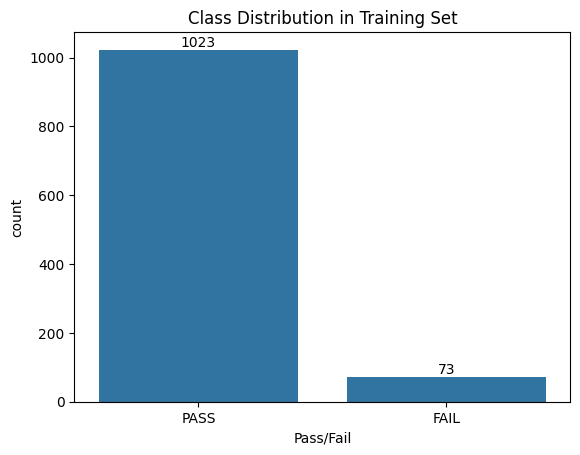

In [144]:
print(y_train.value_counts())
print ("")
ax = sns.countplot(x=y_train)
ax.bar_label(ax.containers[0])
plt.title("Class Distribution in Training Set")
plt.show()

Accuracy: 81.53%


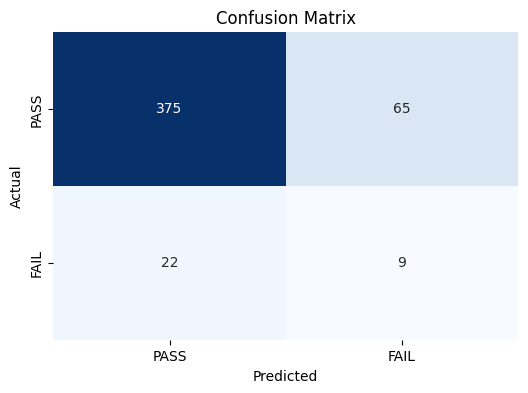

Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.85      0.90       440
        FAIL       0.12      0.29      0.17        31

    accuracy                           0.82       471
   macro avg       0.53      0.57      0.53       471
weighted avg       0.89      0.82      0.85       471



{'Precision_pass': 0.9445843828715366,
 'Precision_os_fail': 0.12162162162162163,
 'Recall_pass': 0.8522727272727273,
 'Recall_fail': 0.2903225806451613,
 'F1-Score_pass': 0.8960573476702509,
 'F1-Score_fail': 0.17142857142857143}

In [145]:
model_imbalanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_imbalanced.fit(X_train, y_train)
evaluate_model_imbalanced(model_imbalanced, X_test, y_test)

## 06b Random Oversampling

In [146]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

oversampler = RandomOverSampler(random_state=32)
X_train_os, y_train_os = oversampler.fit_resample(X_train, y_train)

Pass/Fail
PASS    1023
FAIL    1023
Name: count, dtype: int64



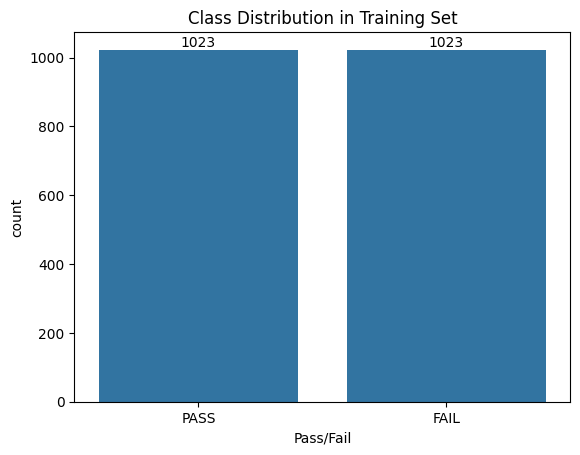

In [147]:
print(y_train_os.value_counts())
print ("")
ax = sns.countplot(x=y_train_os)
ax.bar_label(ax.containers[0])
plt.title("Class Distribution in Training Set")
plt.show()

In [148]:
from sklearn.metrics import accuracy_score

def evaluate_model_silent(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    # Metrics for FAIL (Minority)
    p_f = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    # Metrics for PASS (Majority)
    p_p = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_test, y_pred),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

def evaluate_model_os(model, X_test, y_test, threshold=0.8):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print ("Accuracy: {:.2f}%".format(acc * 100))

    cm = metrics.confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = metrics.classification_report(y_test, y_pred, labels=['PASS', 'FAIL'], zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print ("Classification Report:")
    print (clr)

    precision_os_fail = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    recall_os_fail = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_os_fail = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    precision_os_pass = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    recall_os_pass = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_os_pass = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return { 'Precision_os_pass': precision_os_pass, 'Precision_os_fail': precision_os_fail, 'Recall_os_pass': recall_os_pass, 'Recall_os_fail': recall_os_fail, 'F1-Score_os_pass': f1_os_pass, 'F1-Score_os_fail': f1_os_fail,}

Accuracy: 81.53%


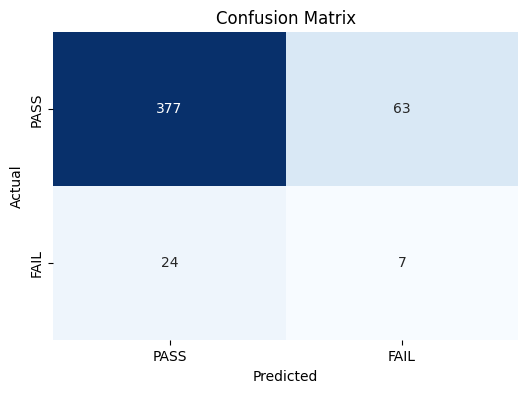

Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.86      0.90       440
        FAIL       0.10      0.23      0.14        31

    accuracy                           0.82       471
   macro avg       0.52      0.54      0.52       471
weighted avg       0.88      0.82      0.85       471



{'Precision_os_pass': 0.940149625935162,
 'Precision_os_fail': 0.1,
 'Recall_os_pass': 0.8568181818181818,
 'Recall_os_fail': 0.22580645161290322,
 'F1-Score_os_pass': 0.896551724137931,
 'F1-Score_os_fail': 0.13861386138613863}

In [149]:
model_os = LogisticRegression(class_weight=None, max_iter=1000)
model_os.fit(X_train_os, y_train_os)
evaluate_model_os(model_os, X_test, y_test)

## 06c Random Oversampling With SMOTE

In [150]:
oversampler = SMOTE(random_state=32)
X_train_SMOTE, y_train_SMOTE = oversampler.fit_resample(X_train, y_train)

Pass/Fail
PASS    1023
FAIL    1023
Name: count, dtype: int64



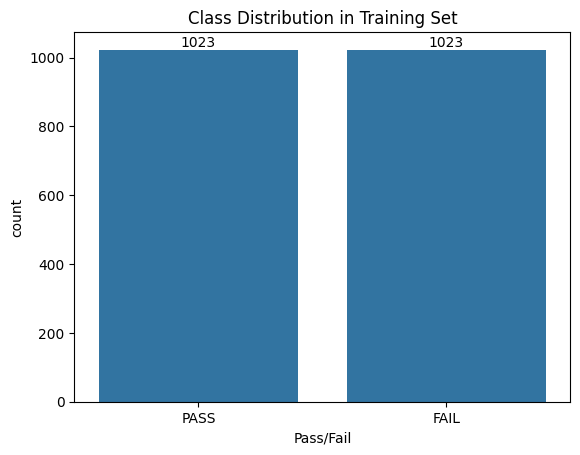

In [151]:
print(y_train_SMOTE.value_counts())
print ("")
ax = sns.countplot(x=y_train_SMOTE)
ax.bar_label(ax.containers[0])
plt.title("Class Distribution in Training Set")
plt.show()

In [152]:
from sklearn.metrics import accuracy_score

def evaluate_model_silent(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    # Metrics for FAIL (Minority)
    p_f = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    # Metrics for PASS (Majority)
    p_p = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_test, y_pred),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

def evaluate_model_SMOTE(model, X_test, y_test, threshold=0.8):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print ("Accuracy: {:.2f}%".format(acc * 100))

    cm = metrics.confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = metrics.classification_report(y_test, y_pred, labels=['PASS', 'FAIL'], zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print ("Classification Report:")
    print (clr)

    precision_SMOTE_fail = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    recall_SMOTE_fail = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_SMOTE_fail = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    precision_SMOTE_pass = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    recall_SMOTE_pass = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_SMOTE_pass = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return { 'Precision_SMOTE_pass': precision_SMOTE_pass, 'Precision_SMOTE_fail': precision_SMOTE_fail, 'Recall_SMOTE_pass': recall_SMOTE_pass, 'Recall_SMOTE_fail': recall_SMOTE_fail, 'F1-Score_SMOTE_pass': f1_SMOTE_pass, 'F1-Score_SMOTE_fail': f1_SMOTE_fail,}

Accuracy: 81.53%


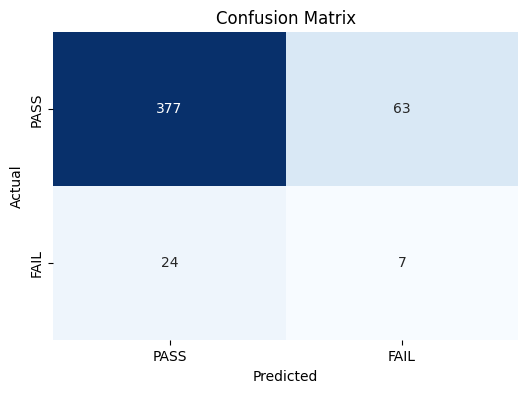

Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.86      0.90       440
        FAIL       0.10      0.23      0.14        31

    accuracy                           0.82       471
   macro avg       0.52      0.54      0.52       471
weighted avg       0.88      0.82      0.85       471



{'Precision_SMOTE_pass': 0.940149625935162,
 'Precision_SMOTE_fail': 0.1,
 'Recall_SMOTE_pass': 0.8568181818181818,
 'Recall_SMOTE_fail': 0.22580645161290322,
 'F1-Score_SMOTE_pass': 0.896551724137931,
 'F1-Score_SMOTE_fail': 0.13861386138613863}

In [153]:
model_SMOTE = LogisticRegression(class_weight=None, max_iter=1000)
model_SMOTE.fit(X_train_SMOTE, y_train_SMOTE)
evaluate_model_SMOTE(model_SMOTE, X_test, y_test)

## 07 Random Forest Model

In [154]:
RFoversampler = SMOTE(sampling_strategy=0.8, random_state=32)
X_train_RF_SMOTE, y_train_RF_SMOTE = RFoversampler.fit_resample(X_train, y_train)

In [155]:
from sklearn.metrics import accuracy_score

def evaluate_model_silent(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    # Metrics for FAIL (Minority)
    p_f = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    # Metrics for PASS (Majority)
    p_p = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_test, y_pred),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

def evaluate_model_RF(model, X_test, y_test, threshold=0.8):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print ("Accuracy: {:.2f}%".format(acc * 100))

    cm = metrics.confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = metrics.classification_report(y_test, y_pred, labels=['PASS', 'FAIL'], zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print ("Classification Report:")
    print (clr)

    precision_RF_fail = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    recall_RF_fail = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_RF_fail = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    precision_RF_pass = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    recall_RF_pass = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_RF_pass = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return { 'Precision_RF_pass': precision_RF_pass, 'Precision_RF_fail': precision_RF_fail, 'Recall_RF_pass': recall_RF_pass, 'Recall_RF_fail': recall_RF_fail, 'F1-Score_RF_pass': f1_RF_pass, 'F1-Score_RF_fail': f1_RF_fail,}

Accuracy: 92.14%


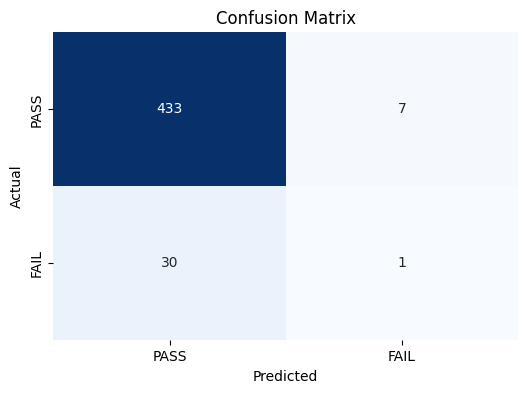

Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.98      0.96       440
        FAIL       0.12      0.03      0.05        31

    accuracy                           0.92       471
   macro avg       0.53      0.51      0.51       471
weighted avg       0.88      0.92      0.90       471

CPU times: user 3.05 s, sys: 3.23 ms, total: 3.05 s
Wall time: 3.07 s


{'Precision_RF_pass': 0.9352051835853131,
 'Precision_RF_fail': 0.125,
 'Recall_RF_pass': 0.9840909090909091,
 'Recall_RF_fail': 0.03225806451612903,
 'F1-Score_RF_pass': 0.9590254706533776,
 'F1-Score_RF_fail': 0.05128205128205128}

In [156]:
%%time

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf = 1,
    min_samples_split = 2,
    max_features = 'sqrt',
    max_samples = 0.9,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train_RF_SMOTE, y_train_RF_SMOTE)
evaluate_model_RF(rf_model, X_test, y_test)


## 07a Random Forest With GridSearchCV

In [157]:
from sklearn.metrics import accuracy_score

def evaluate_model_silent(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    # Metrics for FAIL (Minority)
    p_f = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    # Metrics for PASS (Majority)
    p_p = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_test, y_pred),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

def evaluate_model_GSC(model, X_test, y_test, threshold=0.8):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
   # acc = model.score(X_test, y_test)
    print ("Accuracy: {:.2f}%".format(acc * 100))

   # y_pred = model.predict(X_test)

    cm = metrics.confusion_matrix(y_test, y_pred, labels=['PASS', 'FAIL'])
    clr = metrics.classification_report(y_test, y_pred, labels=['PASS', 'FAIL'], zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.yticks(ticks=[0.5, 1.5], labels=['PASS', 'FAIL'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print ("Classification Report:")
    print (clr)

    precision_GSC_fail = metrics.precision_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    recall_GSC_fail = metrics.recall_score(y_test, y_pred, pos_label='FAIL', zero_division=0)
    f1_GSC_fail = metrics.f1_score(y_test, y_pred, pos_label='FAIL', zero_division=0)

    precision_GSC_pass = metrics.precision_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    recall_GSC_pass = metrics.recall_score(y_test, y_pred, pos_label='PASS', zero_division=0)
    f1_GSC_pass = metrics.f1_score(y_test, y_pred, pos_label='PASS', zero_division=0)

    return { 'Precision_GSC_pass': precision_GSC_pass, 'Precision_GSC_fail': precision_GSC_fail, 'Recall_GSC_pass': recall_GSC_pass, 'Recall_GSC_fail': recall_GSC_fail, 'F1-Score_GSC_pass': f1_GSC_pass, 'F1-Score_GSC_fail': f1_GSC_fail,}

Fitting 1 folds for each of 72 candidates, totalling 72 fits
Accuracy: 91.93%


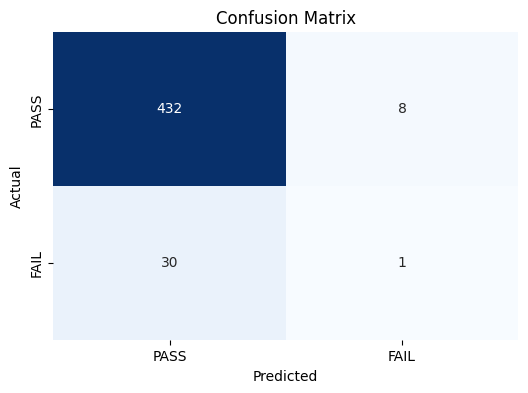

Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.98      0.96       440
        FAIL       0.11      0.03      0.05        31

    accuracy                           0.92       471
   macro avg       0.52      0.51      0.50       471
weighted avg       0.88      0.92      0.90       471



{'Precision_GSC_pass': 0.935064935064935,
 'Precision_GSC_fail': 0.1111111111111111,
 'Recall_GSC_pass': 0.9818181818181818,
 'Recall_GSC_fail': 0.03225806451612903,
 'F1-Score_GSC_pass': 0.9578713968957872,
 'F1-Score_GSC_fail': 0.05}

In [158]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.5, random_state = 0)
split_index = [0 if x in X_val.index else -1 for x in X_train.index]
custom_split = PredefinedSplit(split_index)

rf = RandomForestClassifier(random_state=42)
cv_params = {'n_estimators' : [50,100],
              'max_depth' : [10,50],
              'min_samples_leaf' : [1, 2, 5],
              'class_weight' : ['balanced'],
              'min_samples_split' : [2, 5, 10],
              'max_features' : ["sqrt"],
              'max_samples' : [.5,.9]}

rf_val_GSC = GridSearchCV(rf, cv_params, cv=custom_split, scoring='f1_macro', n_jobs = -1, verbose = 1)
rf_val_GSC.fit(X_train_RF_SMOTE, y_train_RF_SMOTE)

evaluate_model_GSC(rf_val_GSC, X_test, y_test)

## 08 XGBoost


In [159]:
from sklearn.preprocessing import LabelEncoder

def evaluate_model_XGB_silent(model, X_test, y_test_enc, threshold=0.8, name="XGB"):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred_num = (y_prob >= threshold).astype(int)
    y_pred_labels = le.inverse_transform(y_pred_num)
    y_true_labels = le.inverse_transform(y_test_enc)

    # Metrics for FAIL
    p_f = metrics.precision_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)
    r_f = metrics.recall_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)
    f1_f = metrics.f1_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)

    # Metrics for PASS
    p_p = metrics.precision_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)
    r_p = metrics.recall_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)
    f1_p = metrics.f1_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)

    return {
        "Model": name,
        "Accuracy": metrics.accuracy_score(y_true_labels, y_pred_labels),
        "Precision_FAIL": p_f, "Recall_FAIL": r_f, "F1_FAIL": f1_f,
        "Precision_PASS": p_p, "Recall_PASS": r_p, "F1_PASS": f1_p
    }

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_RF_SMOTE)
y_test_enc = le.transform(y_test)

def evaluate_model_XGB(model, X_test, y_test_enc, threshold=0.8):

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred_num = (y_prob >= threshold).astype(int)

    y_pred_labels = le.inverse_transform(y_pred_num)
    y_true_labels = le.inverse_transform(y_test_enc)

    target_order = ['PASS', 'FAIL']

    cm = metrics.confusion_matrix(y_true_labels, y_pred_labels, labels=target_order)
    clr = metrics.classification_report(y_true_labels, y_pred_labels, labels=target_order, zero_division=0)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(ticks=[0.5, 1.5], labels=target_order)
    plt.yticks(ticks=[0.5, 1.5], labels=target_order)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    acc = metrics.accuracy_score(y_true_labels, y_pred_labels)
    print("Accuracy: {:.2f}%".format(acc * 100))
    print ("Classification Report:")
    print (clr)

    precision_XGB_fail = metrics.precision_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)
    recall_XGB_fail = metrics.recall_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)
    f1_XGB_fail = metrics.f1_score(y_true_labels, y_pred_labels, pos_label='FAIL', zero_division=0)

    precision_XGB_pass = metrics.precision_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)
    recall_XGB_pass = metrics.recall_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)
    f1_XGB_pass = metrics.f1_score(y_true_labels, y_pred_labels, pos_label='PASS', zero_division=0)

    return { 'Precision_XGB_pass': precision_XGB_pass, 'Precision_XGB_fail': precision_XGB_fail, 'Recall_XGB_pass': recall_XGB_pass, 'Recall_XGB_fail': recall_XGB_fail, 'F1-Score_XGB_pass': f1_XGB_pass, 'F1-Score_XGB_fail': f1_XGB_fail,}

    print (X_test.shape)
    print (y_test.shape)
    print (y_true_labels.shape)
    print ( y_pred_labels)

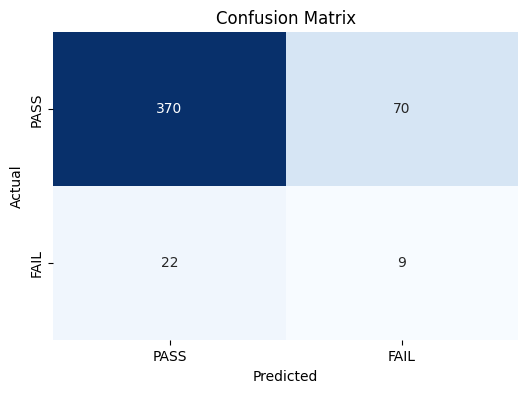

Accuracy: 80.47%
Classification Report:
              precision    recall  f1-score   support

        PASS       0.94      0.84      0.89       440
        FAIL       0.11      0.29      0.16        31

    accuracy                           0.80       471
   macro avg       0.53      0.57      0.53       471
weighted avg       0.89      0.80      0.84       471

CPU times: user 3min 11s, sys: 3.34 s, total: 3min 14s
Wall time: 1min 58s


{'Precision_XGB_pass': 0.9438775510204082,
 'Precision_XGB_fail': 0.11392405063291139,
 'Recall_XGB_pass': 0.8409090909090909,
 'Recall_XGB_fail': 0.2903225806451613,
 'F1-Score_XGB_pass': 0.8894230769230769,
 'F1-Score_XGB_fail': 0.16363636363636364}

In [160]:
%%time

from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.preprocessing import LabelEncoder

xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=0)
cv_params_XGB = {'max_depth': [4, 6],
               'min_child_weight': [3, 5],
               'learning_rate': [0.1, 0.2, 0.3],
               'n_estimators': [5,10,15],
               'subsample': [0.7],
               'colsample_bytree': [0.7]
               }

xgb_cv = GridSearchCV(xgb, cv_params_XGB, scoring = 'f1_macro', cv = 5, refit = 'f1')
xgb_cv.fit(X_train_RF_SMOTE, y_train_enc)

evaluate_model_XGB(xgb_cv.best_estimator_, X_test, y_test_enc)

## 08a XGB Importance Plot

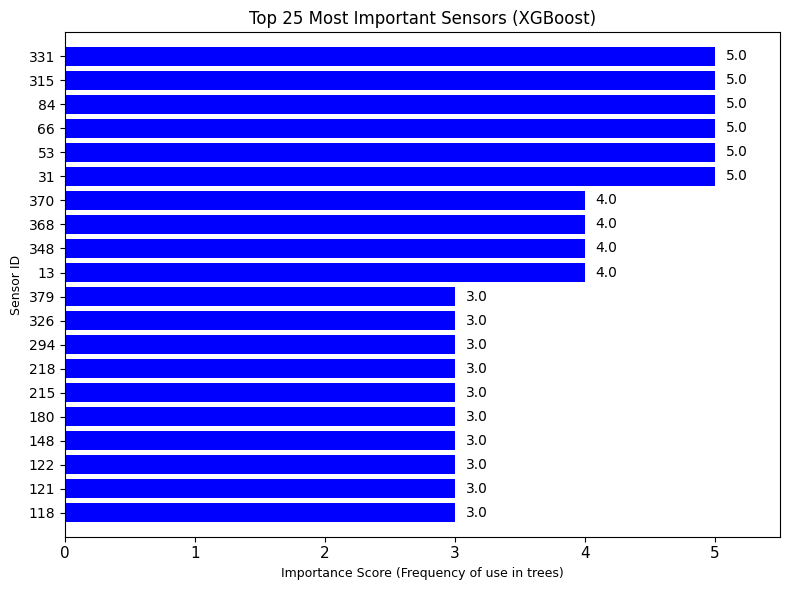

In [161]:
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(8, 6))

plot_importance(xgb_cv.best_estimator_,
                ax=ax,
                max_num_features=20,
                importance_type='weight',
                height=0.8,
                color='blue')

for text in ax.texts:
    x, y = text.get_position()
    text.set_position((x - 0.75, y))
    text.set_horizontalalignment('right')

plt.title("Top 20 Most Important Sensors (XGBoost)", fontsize=12)
plt.xlabel("Importance Score (Frequency of use in trees)", fontsize=9)
plt.ylabel("Sensor ID", fontsize=9)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

## 09 Evaluation Comparison

In [162]:
results = [
    evaluate_model_silent(model_imbalanced, X_test, y_test, name="LR_Imbalance"),
    evaluate_model_silent(model_os, X_test, y_test, name="LR_OS"),
    evaluate_model_silent(model_SMOTE, X_test, y_test, name="LR_OS_SMOTE"),
    evaluate_model_silent(rf_model, X_test, y_test, name="RF_OS_SMOTE"),
    evaluate_model_silent(rf_val_GSC, X_test, y_test, name="RF_GSCV_OS_SMOTE"),
    evaluate_model_XGB_silent(xgb_cv.best_estimator_, X_test, y_test_enc, name="XGB_OS_SMOTE")
]

df_combined = pd.DataFrame(results)
df_combined.round(4)

,Model,Accuracy,Precision_FAIL,Recall_FAIL,F1_FAIL,Precision_PASS,Recall_PASS,F1_PASS
0,LR_Imbalance,0.8153,0.1216,0.2903,0.1714,0.9446,0.8523,0.8961
1,LR_OS,0.8153,0.1000,0.2258,0.1386,0.9401,0.8568,0.8966
2,LR_OS_SMOTE,0.8153,0.1000,0.2258,0.1386,0.9401,0.8568,0.8966
3,RF_OS_SMOTE,0.9214,0.1250,0.0323,0.0513,0.9352,0.9841,0.9590
4,RF_GSCV_OS_SMOTE,0.9193,0.1111,0.0323,0.0500,0.9351,0.9818,0.9579
5,XGB_OS_SMOTE,0.8047,0.1139,0.2903,0.1636,0.9439,0.8409,0.8894


In [163]:
df_combined["Precision Gap"] = df_combined["Precision_PASS"] - df_combined["Precision_FAIL"]
df_combined["Recall Gap"] = df_combined["Recall_PASS"] - df_combined["Recall_FAIL"]
df_combined['F1 Gap'] = df_combined['F1_PASS'] - df_combined['F1_FAIL']
df_combined['F1 Macro'] = ((df_combined['F1_PASS'] + df_combined['F1_FAIL']) / 2).round(4)
df_combined.round(4)

,Model,Accuracy,Precision_FAIL,Recall_FAIL,F1_FAIL,Precision_PASS,Recall_PASS,F1_PASS,Precision Gap,Recall Gap,F1 Gap,F1 Macro
0,LR_Imbalance,0.8153,0.1216,0.2903,0.1714,0.9446,0.8523,0.8961,0.8230,0.5620,0.7246,0.5337
1,LR_OS,0.8153,0.1000,0.2258,0.1386,0.9401,0.8568,0.8966,0.8401,0.6310,0.7579,0.5176
2,LR_OS_SMOTE,0.8153,0.1000,0.2258,0.1386,0.9401,0.8568,0.8966,0.8401,0.6310,0.7579,0.5176
3,RF_OS_SMOTE,0.9214,0.1250,0.0323,0.0513,0.9352,0.9841,0.9590,0.8102,0.9518,0.9077,0.5052
4,RF_GSCV_OS_SMOTE,0.9193,0.1111,0.0323,0.0500,0.9351,0.9818,0.9579,0.8240,0.9496,0.9079,0.5039
5,XGB_OS_SMOTE,0.8047,0.1139,0.2903,0.1636,0.9439,0.8409,0.8894,0.8300,0.5506,0.7258,0.5265


## 09a Accuracy

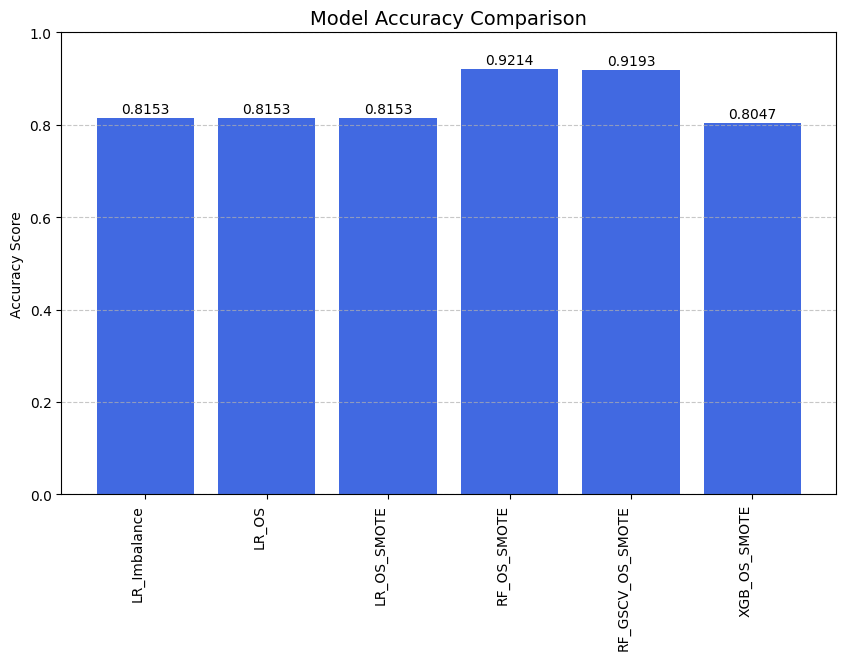

In [173]:
plt.figure(figsize=(10, 6))
# Plotting Accuracy
plt.bar(df_combined['Model'], df_combined['Accuracy'], color='royalblue')

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy Score')
plt.xticks(rotation=90, ha="right", fontsize=10)
plt.ylim(0, 1.0) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding value labels on top of bars
for i, val in enumerate(df_combined['Accuracy']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center')

plt.show()

## 09b Precision

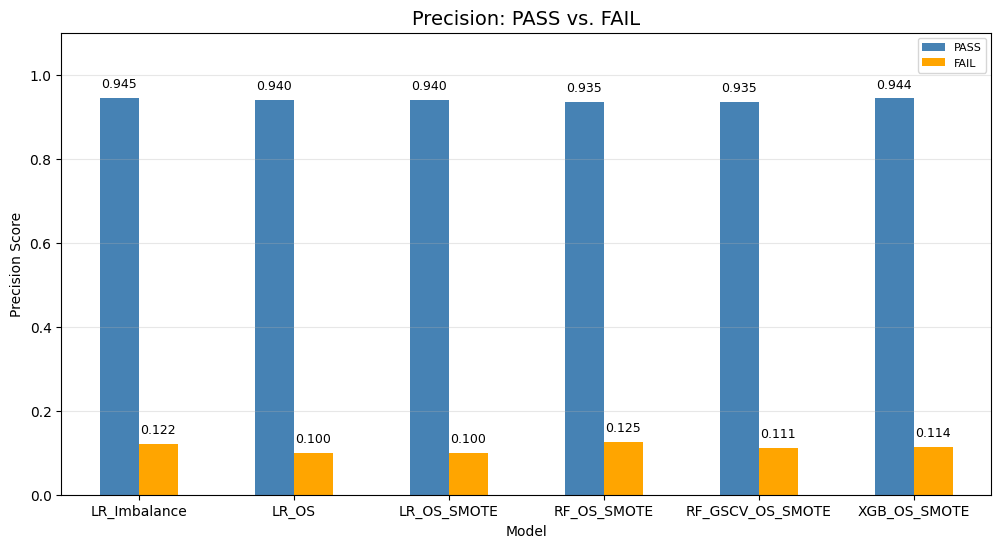

In [174]:
# Setting up the grouped bar chart
ax = df_combined.plot(x='Model', y=['Precision_PASS', 'Precision_FAIL'],
                      kind='bar', figsize=(12, 6), color=['steelblue', 'orange'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=9)

plt.title('Precision: PASS vs. FAIL', fontsize=14)
plt.ylabel('Precision Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(["PASS", "FAIL"], fontsize=8)
plt.grid(axis='y', alpha=0.3)


plt.show()

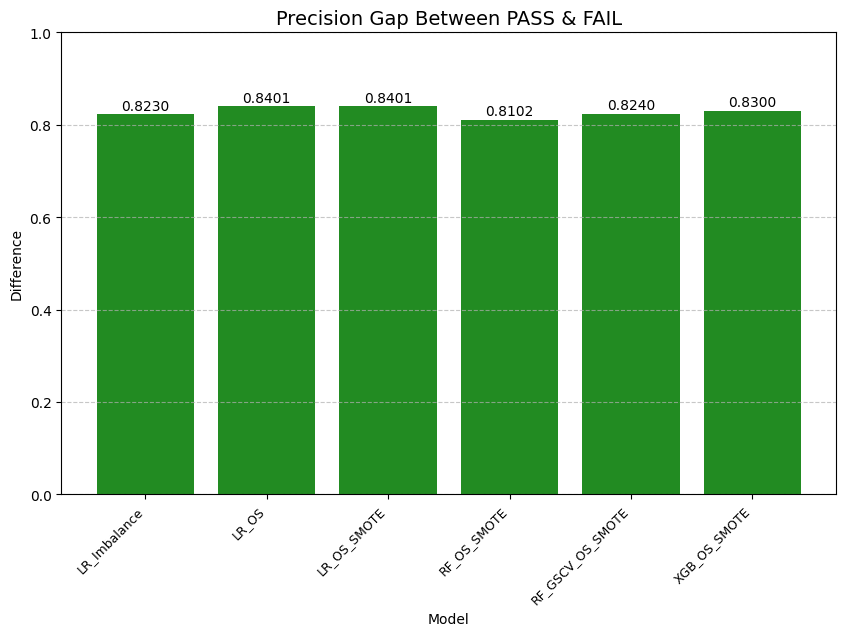

In [166]:
plt.figure(figsize=(10, 6))
plt.bar(df_combined['Model'], df_combined['Precision Gap'], color='forestgreen')

plt.title('Precision Gap Between PASS & FAIL', fontsize=14)
plt.ylabel('Difference')
plt.xlabel('Model')
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(df_combined['Precision Gap']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center')

plt.show()

## 09c Recall

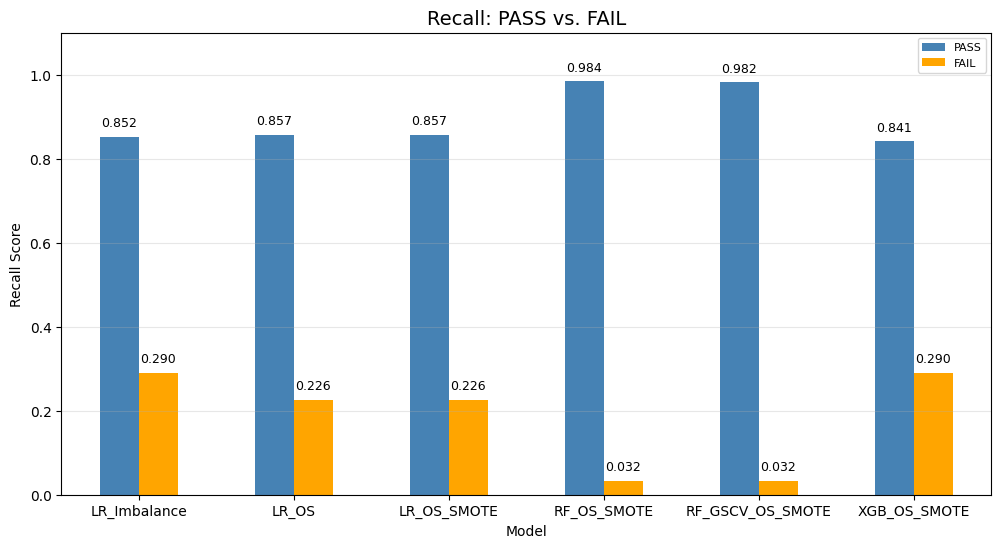

In [175]:
ax = df_combined.plot(x='Model', y=['Recall_PASS', 'Recall_FAIL'],
                      kind='bar', figsize=(12, 6), color=['steelblue', 'orange'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=9)

plt.title('Recall: PASS vs. FAIL', fontsize=14)
plt.ylabel('Recall Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(["PASS", "FAIL"], fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.show()

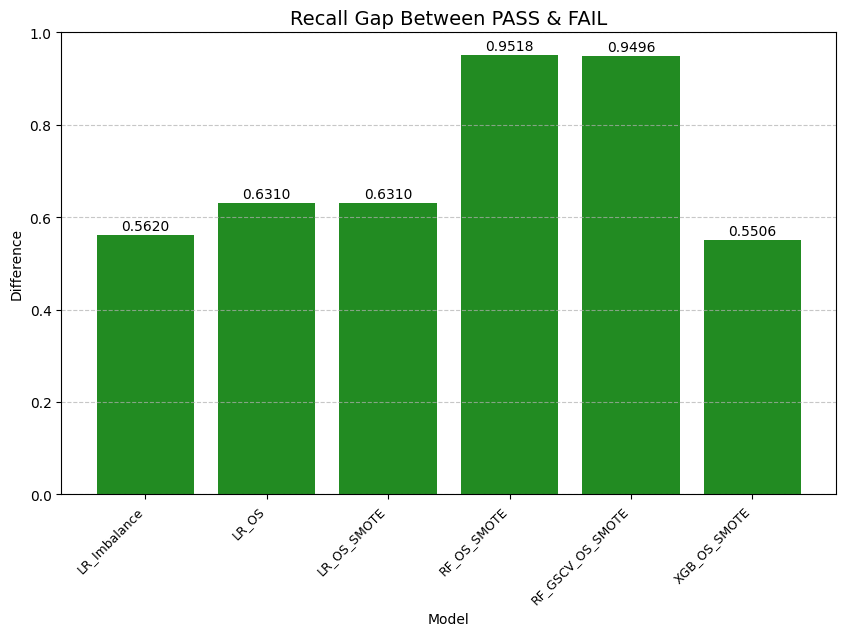

In [168]:
plt.figure(figsize=(10, 6))
plt.bar(df_combined['Model'], df_combined['Recall Gap'], color='forestgreen')

plt.title('Recall Gap Between PASS & FAIL', fontsize=14)
plt.ylabel('Difference')
plt.xlabel('Model')
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(df_combined['Recall Gap']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center')

plt.show()

## 09d F1 Score

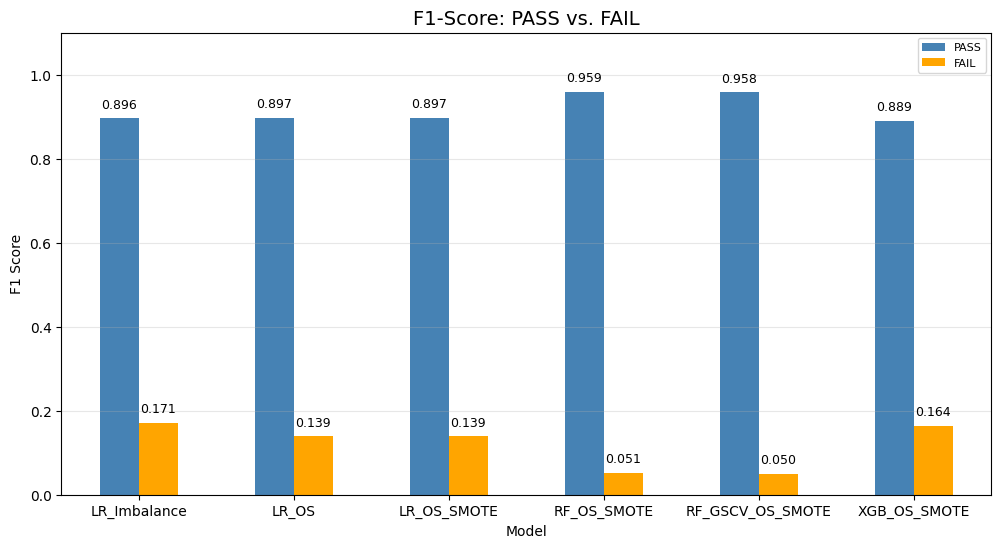

In [176]:
ax = df_combined.plot(x='Model', y=['F1_PASS', 'F1_FAIL'],
                      kind='bar', figsize=(12, 6), color=['steelblue', 'orange'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=9)

plt.title('F1-Score: PASS vs. FAIL', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(["PASS", "FAIL"], fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.show()

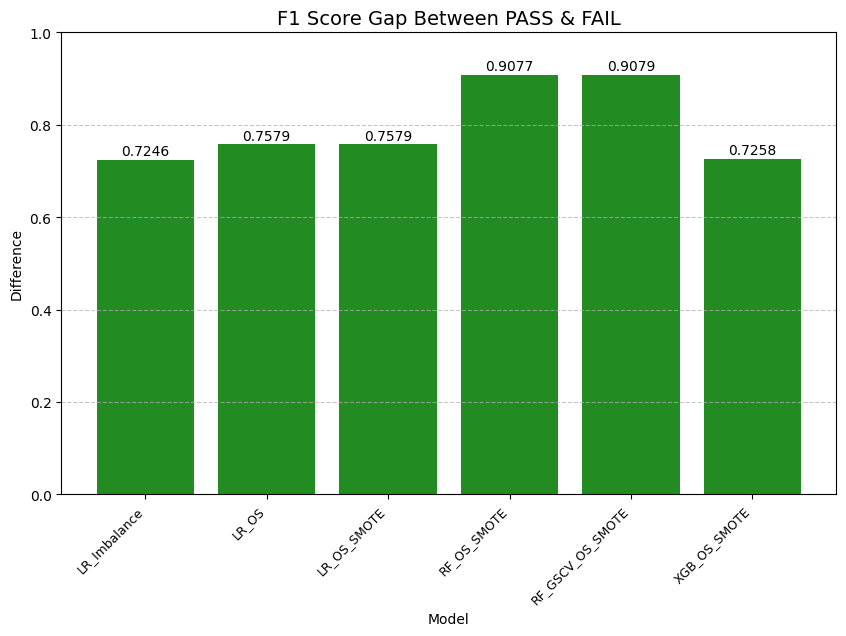

In [179]:
plt.figure(figsize=(10, 6))
plt.bar(df_combined['Model'], df_combined['F1 Gap'], color='forestgreen')

plt.title('F1 Score Gap Between PASS & FAIL', fontsize=14)
plt.ylabel('Difference')
plt.xlabel('Model')
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(df_combined['F1 Gap']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center')

plt.show()

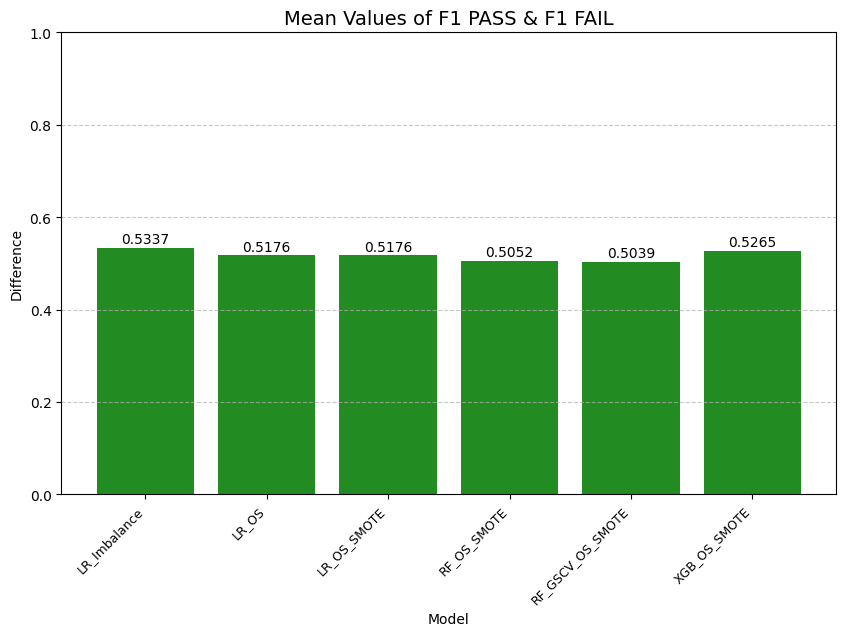

In [171]:
plt.figure(figsize=(10, 6))
plt.bar(df_combined['Model'], df_combined['F1 Macro'], color='forestgreen')

plt.title('Mean Values of F1 PASS & F1 FAIL', fontsize=14)
plt.ylabel('Difference')
plt.xlabel('Model')
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(df_combined['F1 ']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center')

plt.show()